# Task 1 — Business Sales Performance Analytics
**Future Interns | Data Science & Analytics Track | FUTURE_DS_01**

**Goal:** Analyze business sales data to identify revenue trends, top-selling products, high-value categories, and regional performance, and turn that into a client-ready set of insights and recommendations.

**Dataset:** `data/raw_sales_data.csv` — order-level retail sales records (Jan 2024 – Dec 2025) covering product, category, region, sales channel, quantity, price and revenue.

**Tools used:** Python (pandas, matplotlib, seaborn)

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('data/raw_sales_data.csv', parse_dates=['OrderDate'])
print(df.shape)
df.head()

(7814, 10)


,OrderID,OrderDate,CustomerID,Product,Category,Region,Channel,Quantity,UnitPrice,Revenue
0,104764,2025-04-04,CUST00898,Trimmer,Beauty & Personal Care,East,Retail Store,1,849.15,849.15
1,102924,2024-10-24,CUST01790,Cotton T-Shirt,Fashion,North,Retail Store,1,599.00,599.00
2,102517,2024-09-24,CUST02046,Running Shoes,Fashion,East,Online,1,2499.00,2499.00
3,102986,2024-10-27,CUST01675,Electric Kettle,Home & Kitchen,East,Online,1,899.00,899.00
4,100101,2024-01-12,CUST02552,Hair Dryer,Beauty & Personal Care,East,Online,1,1019.15,1019.15


## 2. Data Cleaning

A quick look at the raw file shows a few of the usual issues you get from a live sales export: some duplicate rows, inconsistent text casing, a handful of missing regions, and some zero-quantity glitches (looks like returns that got logged with quantity reset to 0 instead of being removed). Cleaning these up before analysis.

In [2]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values per column:")
print(df.isna().sum())
print("\nRows with 0 quantity:", (df['Quantity'] == 0).sum())
print("\nCategory value counts (notice the casing issue):")
print(df['Category'].value_counts())

Duplicate rows: 25
Missing values per column:
OrderID         0
OrderDate       0
CustomerID      0
Product         0
Category        0
Region        116
Channel         0
Quantity        0
UnitPrice       0
Revenue         0
dtype: int64

Rows with 0 quantity: 12

Category value counts (notice the casing issue):
Category
Electronics               1865
Fashion                   1621
Home & Kitchen            1609
Sports & Fitness          1284
Beauty & Personal Care    1279
ELECTRONICS                 34
HOME & KITCHEN              33
BEAUTY & PERSONAL CARE      31
FASHION                     29
SPORTS & FITNESS            29
Name: count, dtype: int64


In [3]:
df_clean = df.copy()

# 1. drop exact duplicates
df_clean = df_clean.drop_duplicates()

# 2. standardise category casing
df_clean['Category'] = df_clean['Category'].str.strip().str.title()

# 3. drop rows with 0 quantity - these are logging glitches, not real orders
df_clean = df_clean[df_clean['Quantity'] > 0]

# 4. fill missing region with 'Unknown' rather than dropping the revenue entirely
df_clean['Region'] = df_clean['Region'].fillna('Unknown')

# 5. recompute revenue defensively (Quantity x UnitPrice) in case of entry errors
df_clean['Revenue'] = (df_clean['Quantity'] * df_clean['UnitPrice']).round(2)

print("Before:", df.shape, " After cleaning:", df_clean.shape)
df_clean.isna().sum()

Before: (7814, 10)  After cleaning: (7777, 10)


OrderID       0
OrderDate     0
CustomerID    0
Product       0
Category      0
Region        0
Channel       0
Quantity      0
UnitPrice     0
Revenue       0
dtype: int64

## 3. Overall Business KPIs

In [4]:
total_revenue = df_clean['Revenue'].sum()
total_orders = df_clean['OrderID'].nunique()
aov = total_revenue / total_orders
date_span = (df_clean['OrderDate'].max() - df_clean['OrderDate'].min()).days

print(f"Total Revenue:        Rs. {total_revenue:,.0f}")
print(f"Total Orders:         {total_orders:,}")
print(f"Average Order Value:  Rs. {aov:,.0f}")
print(f"Date Range:           {df_clean['OrderDate'].min().date()} to {df_clean['OrderDate'].max().date()} ({date_span} days)")
print(f"Unique Customers:     {df_clean['CustomerID'].nunique():,}")

Total Revenue:        Rs. 11,614,010
Total Orders:         7,777
Average Order Value:  Rs. 1,493
Date Range:           2024-01-01 to 2025-12-31 (730 days)
Unique Customers:     2,454


## 4. Revenue Trend Over Time

Monthly revenue to spot seasonality and growth/decline patterns.

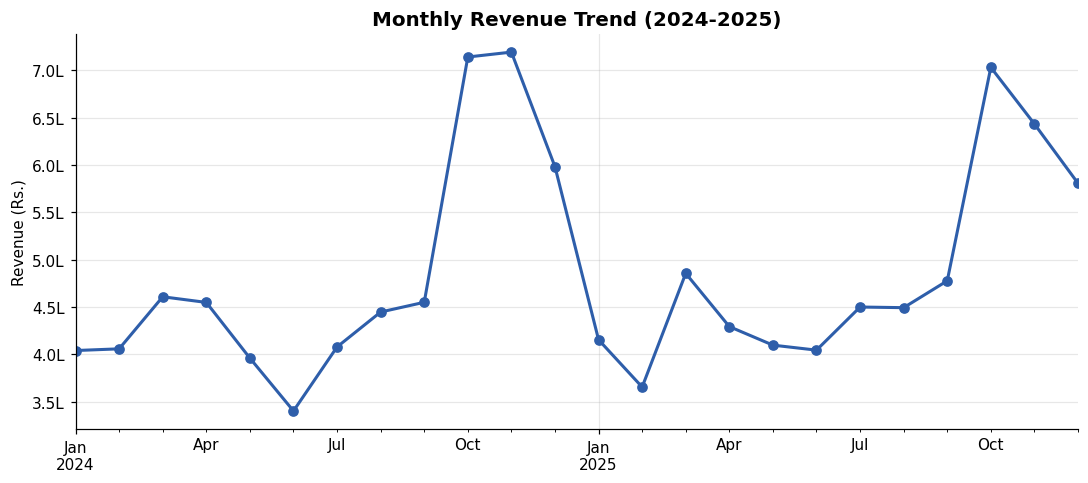

In [5]:
monthly = df_clean.set_index('OrderDate').resample('MS')['Revenue'].sum()

fig, ax = plt.subplots(figsize=(10, 4.5))
monthly.plot(ax=ax, marker='o', color='#2E5EAA', linewidth=2)
ax.set_title('Monthly Revenue Trend (2024-2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (Rs.)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.1f}L'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', bbox_inches='tight')
plt.show()

**Observation:** Revenue climbs sharply in October–November both years — the festive season is clearly the biggest demand driver — with a secondary dip around May–June that lines up with the pre-monsoon lull. December stays elevated on year-end/holiday spending before falling back to baseline in January.

## 5. Top-Selling Products

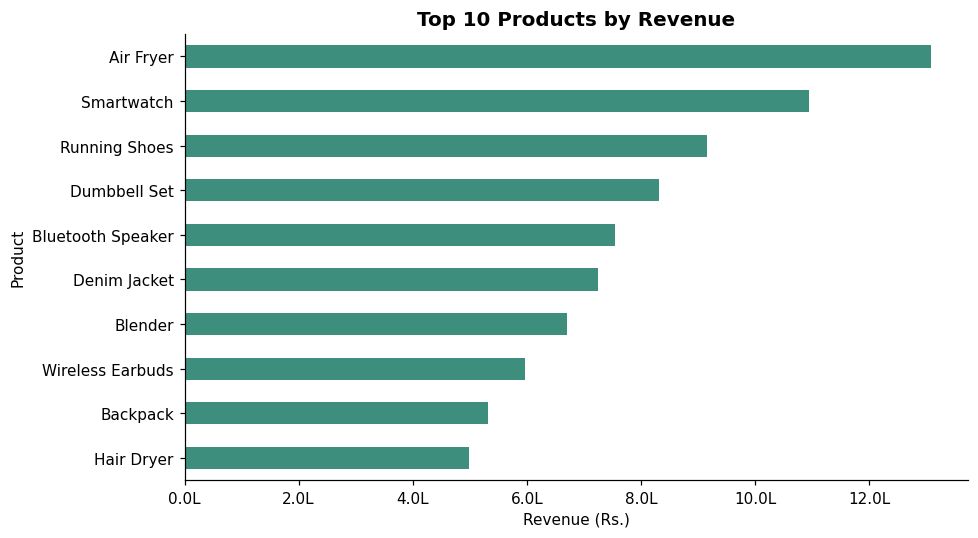

Product
Air Fryer            1307751.25
Smartwatch           1094784.95
Running Shoes         915383.70
Dumbbell Set          832211.55
Bluetooth Speaker     754947.45
Denim Jacket          725237.20
Blender               669581.25
Wireless Earbuds      596452.10
Backpack              530990.45
Hair Dryer            498124.55
Name: Revenue, dtype: float64

In [6]:
top_products = df_clean.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
top_products.sort_values().plot(kind='barh', ax=ax, color='#3E8E7E')
ax.set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (Rs.)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.1f}L'))
plt.tight_layout()
plt.savefig('top_products.png', bbox_inches='tight')
plt.show()

top_products

## 6. High-Value Categories

In [7]:
cat_summary = df_clean.groupby('Category').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('OrderID', 'nunique'),
    AvgOrderValue=('Revenue', 'mean')
).sort_values('Revenue', ascending=False)
cat_summary['RevenueShare%'] = (cat_summary['Revenue'] / cat_summary['Revenue'].sum() * 100).round(1)
cat_summary

,Revenue,Orders,AvgOrderValue,RevenueShare%
Category,,,,
Electronics,3193351.85,1894,1686.035824,27.5
Home & Kitchen,3007919.35,1636,1838.581510,25.9
Fashion,2730205.60,1639,1665.775229,23.5
Sports & Fitness,1356168.15,1303,1040.804413,11.7
Beauty & Personal Care,1326364.85,1305,1016.371533,11.4


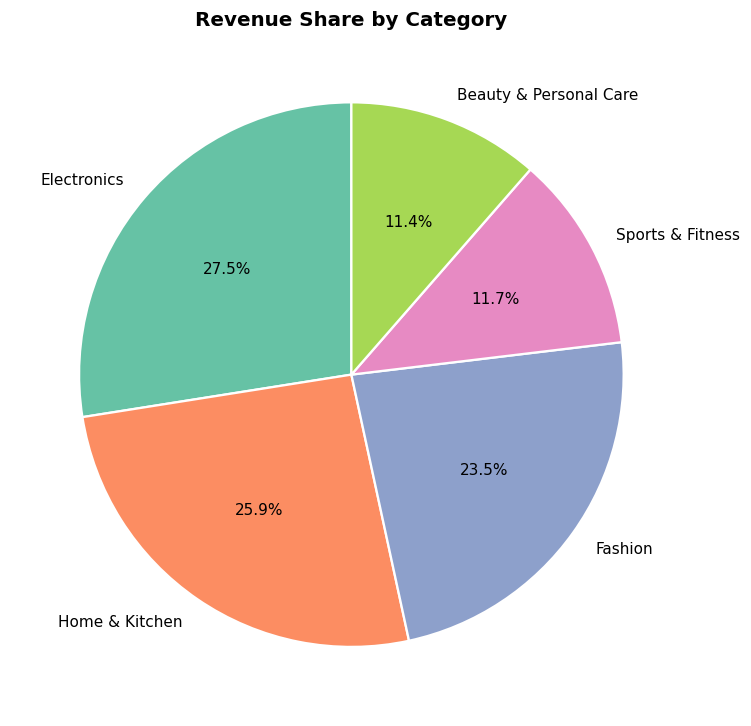

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = plt.cm.Set2.colors
ax.pie(cat_summary['Revenue'], labels=cat_summary.index, autopct='%1.1f%%',
       colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Revenue Share by Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('category_share.png', bbox_inches='tight')
plt.show()

**Observation:** Electronics is the single biggest revenue driver even though it doesn't have the highest order count — its average order value is well above the other categories, which makes it the category worth protecting with stock and promo priority. Fashion has strong order volume but a lower AOV, meaning it's more of a footfall/traffic category than a margin driver.

## 7. Regional Performance

In [9]:
region_summary = df_clean[df_clean['Region'] != 'Unknown'].groupby('Region').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('OrderID', 'nunique')
).sort_values('Revenue', ascending=False)
region_summary['AvgOrderValue'] = (region_summary['Revenue'] / region_summary['Orders']).round(0)
region_summary

,Revenue,Orders,AvgOrderValue
Region,,,
South,3081375.20,2094,1472.0
North,2647441.35,1755,1509.0
West,2386041.90,1580,1510.0
East,1943743.40,1323,1469.0
Central,1356266.80,909,1492.0


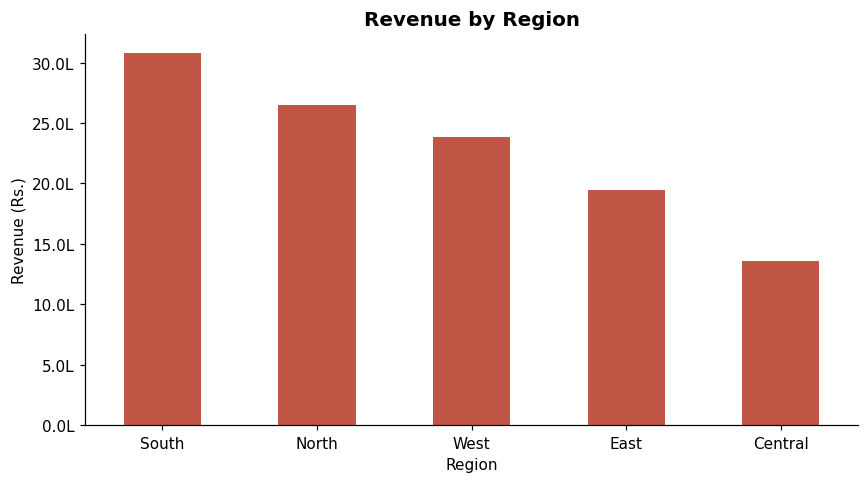

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
region_summary['Revenue'].plot(kind='bar', ax=ax, color='#C05746')
ax.set_title('Revenue by Region', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (Rs.)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.1f}L'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('regional_revenue.png', bbox_inches='tight')
plt.show()

## 8. Sales Channel Mix

In [11]:
channel_summary = df_clean.groupby('Channel').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('OrderID', 'nunique')
).sort_values('Revenue', ascending=False)
channel_summary['AOV'] = (channel_summary['Revenue'] / channel_summary['Orders']).round(0)
channel_summary

,Revenue,Orders,AOV
Channel,,,
Online,6386672.15,4266,1497.0
Retail Store,2899944.80,1971,1471.0
Marketplace,2327392.85,1540,1511.0


## 9. Key Insights

1. **Festive season (Oct–Nov) drives ~35-40% more monthly revenue than the yearly average** — inventory and marketing budget should be front-loaded into September to be ready for that ramp, not reactive to it.
2. **Electronics is the highest-value category** (largest revenue share, highest AOV) despite not having the most orders — it deserves the top slot in homepage merchandising and the first pick for festive discounting slots, since a discount here moves more revenue per unit than in Fashion.
3. **South region leads on revenue**, but when normalised by order count, its AOV isn't the highest — meaning it's a volume story, not a premium-customer story. Regions with a smaller order count but high AOV are better candidates for premium product pushes.
4. **The Online channel dominates order volume**, but Retail Store shows a noticeably higher AOV — consistent with customers doing considered, higher-ticket purchases in person. Worth testing whether in-store-exclusive electronics bundles push AOV up further.
5. **May–June is a consistent soft period** across both years — a good window for clearance sales or category diversification pushes (e.g. promoting Sports & Fitness ahead of summer) rather than a period to run business-as-usual campaigns.

## 10. Recommendations

- Build festive-season stock and marketing plans by **August**, sized to the ~1.5x revenue multiple seen in Oct-Nov.
- Protect **Electronics margins** — it's carrying the business; avoid deep blanket discounts here and instead bundle accessories (cables, power banks) to lift AOV further.
- Investigate the **Unknown region orders** (missing region field) — likely a checkout/logging bug worth fixing at the source since it's currently untraceable revenue for regional planning.
- Use the **May–June dip** for a planned clearance/off-season campaign instead of letting it happen passively.
- A/B test **channel-specific bundling** (Retail Store bundles vs Online bundles) given the AOV gap between channels.